# Data Preparation

In [1]:
import pandas as pd

from src.compare import compare_transformations, compare_skewness, compare_distributions
from src.descriptions import stitched_measurements, stitched_descriptions
from src.eda import understand_features, assess_features
from src.enums import keys, prefixes, measurements, file
from src.transform import Transformation, transform

aq = pd.read_csv(file['data/04-01-open-meteo-cleaned-aggregated.csv'])
rv = pd.read_csv(file['data/04-01-respiratory-virus-dashboard-cleaned-transformed.csv'])

## Stabilize air quality data

Further analysis showed that previously stabilized data become skewed again after aggregation. Also, previously extremely skewed columns can now be stabilized with transformations. We are applying stabilization to these columns again.

Features that cannot be stabilized would have been discretized.

### Compare skewness across different transformations

In [2]:
compare_transformations(aq)

,Original,Square root,Log transformation,Cube root,Yeo-Johnson Transform
SEASON,N/A,N/A,N/A,N/A,N/A
WEEKENDING,N/A,N/A,N/A,N/A,N/A
MMWR_WEEK,-0.19,-0.69,-1.25,-0.91,-0.32
MMWR_YEAR,-0.06,-0.06,-0.06,-0.06,-0.03
us_aqi (USAQI),1.54,1.03,0.63,0.88,0.03
us_aqi_pm2_5 (USAQI),0.59,0.16,-0.27,0.01,0.01
us_aqi_pm10 (USAQI),0.71,0.36,0.05,0.24,0.0
us_aqi_nitrogen_dioxide (USAQI),-0.21,-0.47,-0.75,-0.57,-0.19
us_aqi_carbon_monoxide (USAQI),1.0,0.58,0.35,0.45,0.07
us_aqi_ozone (USAQI),2.04,1.39,0.84,1.19,-0.03


### Transform skewed features

In [3]:
transformations = {
    keys['us_aqi_pm2_5 (USAQI)']: Transformation.SQRT,
    keys['us_aqi_pm10 (USAQI)']: Transformation.SQRT,
    keys['us_aqi_sulphur_dioxide (USAQI)']: Transformation.SQRT,
    keys['aerosol_optical_depth ()']: Transformation.SQRT,
    keys['nitrogen_dioxide (μg/m³)']: Transformation.SQRT,
    keys['pm10 (μg/m³)']: Transformation.SQRT,

    keys['us_aqi_carbon_monoxide (USAQI)']: Transformation.LOG1P,
    keys['pm2_5 (μg/m³)']: Transformation.LOG1P,
    keys['carbon_monoxide (μg/m³)']: Transformation.LOG1P,

    keys['us_aqi (USAQI)']: Transformation.YEO_JOHNSON,
    keys['us_aqi_ozone (USAQI)']: Transformation.YEO_JOHNSON,
    keys['dust (μg/m³)']: Transformation.YEO_JOHNSON,
    keys['sulphur_dioxide (μg/m³)']: Transformation.YEO_JOHNSON,
}
aq_transformed = transform(
    aq,
    transformations,
    prefixes['04_01_data_preparation_']
)

### Skewness comparison

In [4]:
compare_skewness(aq, aq_transformed, transformations)

,Changes,Skewness (Original),Skewness (Target)
us_aqi_pm2_5 (USAQI),sqrt,0.59,0.16
us_aqi_pm10 (USAQI),sqrt,0.71,0.36
us_aqi_sulphur_dioxide (USAQI),sqrt,1.37,0.47
aerosol_optical_depth (),sqrt,0.65,0.31
nitrogen_dioxide (μg/m³),sqrt,0.8,0.45
pm10 (μg/m³),sqrt,0.55,0.2
us_aqi_carbon_monoxide (USAQI),log1p,1.0,0.35
pm2_5 (μg/m³),log1p,1.22,0.4
carbon_monoxide (μg/m³),log1p,1.26,0.52
us_aqi (USAQI),yeo-johnson,1.54,0.03


### Distribution comparison

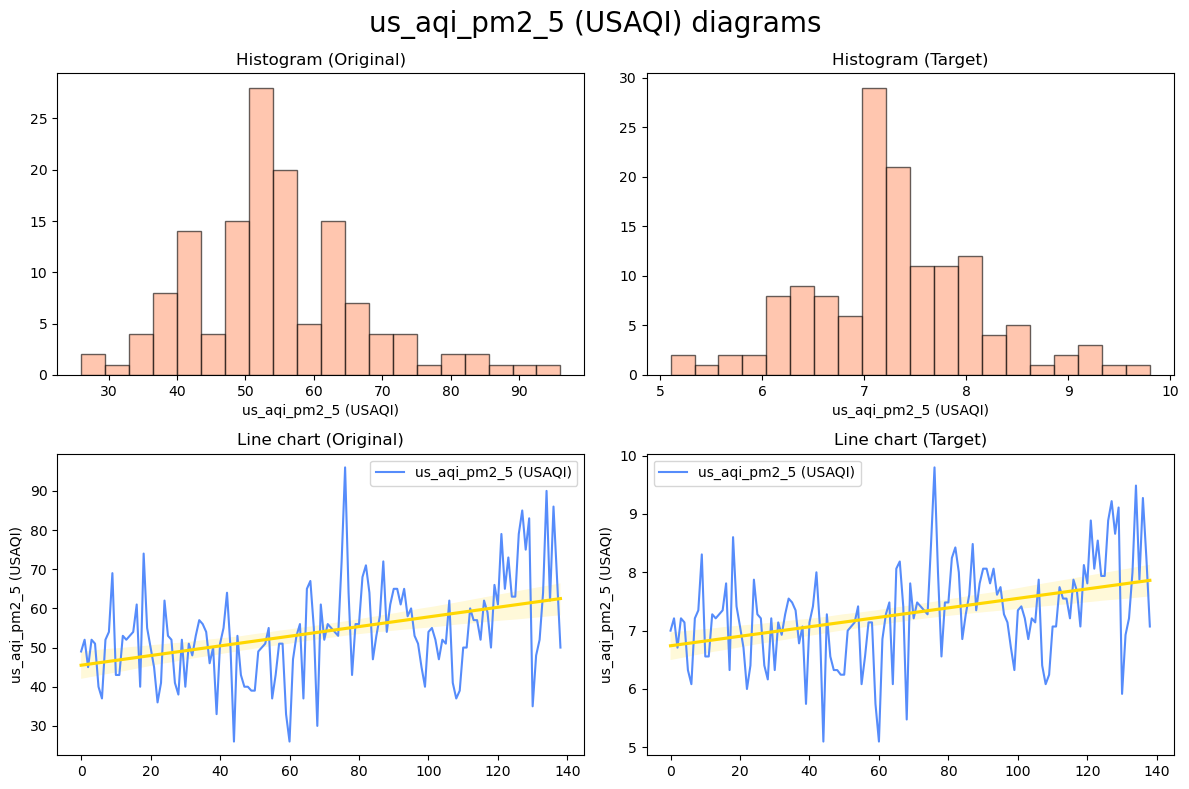

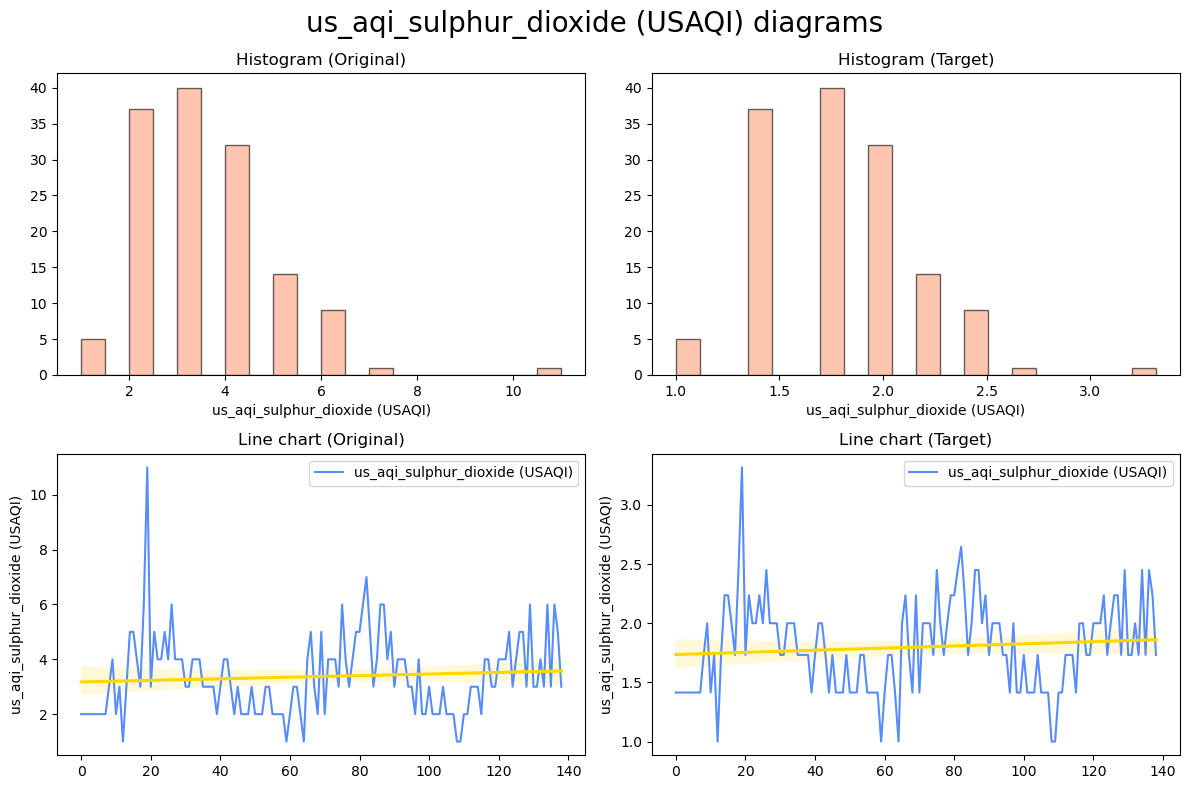

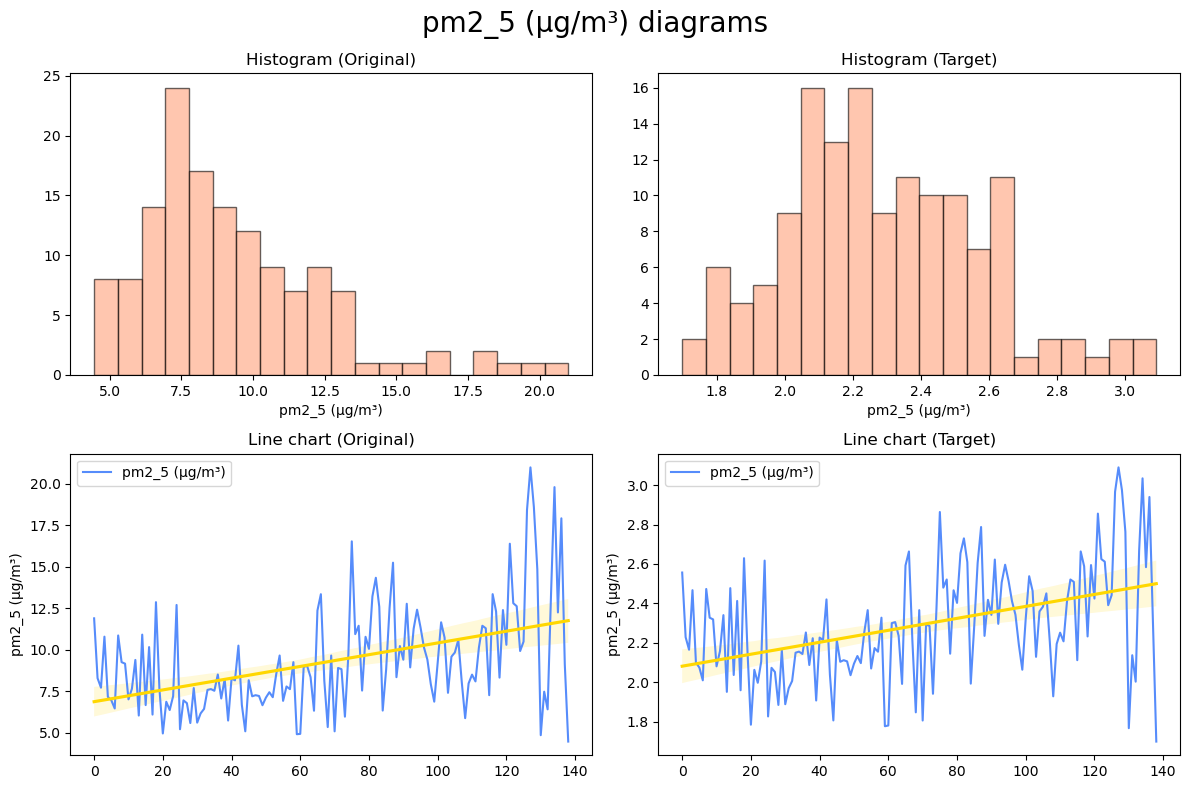

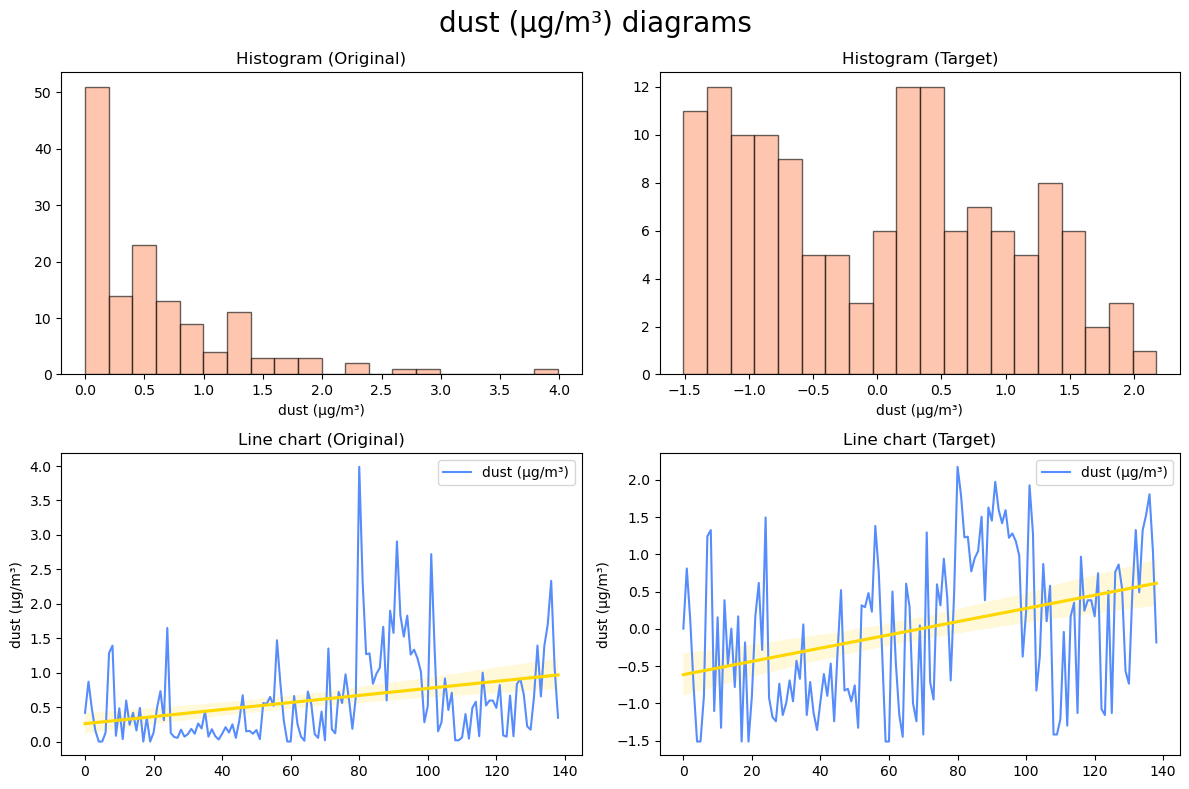

In [5]:
compare_distributions(
    aq,
    aq_transformed,
    [
        keys['us_aqi_pm2_5 (USAQI)'], # square root transformation.
        keys['us_aqi_sulphur_dioxide (USAQI)'], # square root transformation.
        keys['pm2_5 (μg/m³)'], # log transformation.
        keys['dust (μg/m³)'] # Yeo-Johnson transformation.
    ]
)

## Discretize categorical features

Discretize categorical columns so that they can be correlated with numeric columns.

### Determine value counts for each column

In [6]:
value_counts = pd.concat([
    rv[keys['COV_TP_LEVEL']].value_counts(),
    rv[keys['FLU_TP_LEVEL']].value_counts(),
    rv[keys['RSV_TP_LEVEL']].value_counts(),
], axis=1)
value_counts.columns = [keys['COV_TP_LEVEL'], keys['FLU_TP_LEVEL'], keys['RSV_TP_LEVEL']]

value_counts

,COV_TP_LEVEL,FLU_TP_LEVEL,RSV_TP_LEVEL
Very Low,60.0,19,60
Low,51.0,74,31
Moderate,28.0,11,25
High,1.0,25,11
Very High,NaN,11,13


### Convert discrete strings to ordinal values

In [7]:
rv_discretized = rv.copy();

level_order = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']

rv_discretized[keys['COV_TP_LEVEL']] = pd.Categorical(
    rv_discretized[keys['COV_TP_LEVEL']],
    categories=level_order,
    ordered=True
)
rv_discretized[keys['FLU_TP_LEVEL']] = pd.Categorical(
    rv_discretized[keys['FLU_TP_LEVEL']],
    categories=level_order,
    ordered=True
)
rv_discretized[keys['RSV_TP_LEVEL']] = pd.Categorical(
    rv_discretized[keys['RSV_TP_LEVEL']],
    categories=level_order,
    ordered=True
)

rv_preview = rv_discretized.copy()
rv_preview[keys['COV_TP_LEVEL'] + '_order'] = rv_preview[keys['COV_TP_LEVEL']].cat.codes
rv_preview[keys['FLU_TP_LEVEL'] + '_order'] = rv_preview[keys['FLU_TP_LEVEL']].cat.codes
rv_preview[keys['RSV_TP_LEVEL'] + '_order'] = rv_preview[keys['RSV_TP_LEVEL']].cat.codes

rv_preview.head(3)

,SEASON,WEEKENDING,MMWR_WEEK,MMWR_YEAR,COV_POSITIVES,COV_TOTAL_TESTS,COV_TP,COV_TP_LEVEL,FLU_POSITIVES,FLU_TOTAL_TESTS,...,TOTAL_DEATHS,COV_DEATHS,FLU_DEATHS,RSV_DEATHS,COV_DEATHS_PER,FLU_DEATHS_PER,RSV_DEATHS_PER,COV_TP_LEVEL_order,FLU_TP_LEVEL_order,RSV_TP_LEVEL_order
0,2023/2024,07/08/2023,27,2023,42.414620,40924,2.096653,Low,4.248495,39.306488,...,-0.263756,4.690416,-0.266598,-0.919797,1.435244,-0.451111,-0.887000,1,1,0
1,2023/2024,07/15/2023,28,2023,45.276926,41354,2.226477,Low,4.532599,40.865633,...,-0.842204,4.000000,-1.299923,-0.919797,1.256768,-1.138038,-0.887000,1,1,0
2,2023/2024,07/22/2023,29,2023,47.180504,41390,2.319075,Low,3.850148,39.127995,...,-0.545089,4.123106,-1.299923,0.463280,1.277293,-1.138038,0.323507,1,1,0


## Stitch data
Combine datasets through their SEASON, WEEKENDING, MMWR_WEEK, MMWR_YEAR features.

In [8]:
df = pd.merge(
    aq_transformed,
    rv_discretized,
    on=[
        keys['SEASON'],
        keys['WEEKENDING'],
        keys['MMWR_WEEK'],
        keys['MMWR_YEAR']
    ],
    how='inner'
)

print(f'Row length: {len(df)}')
df.head(3)

Row length: 138


,SEASON,WEEKENDING,MMWR_WEEK,MMWR_YEAR,us_aqi (USAQI),us_aqi_pm2_5 (USAQI),us_aqi_pm10 (USAQI),us_aqi_nitrogen_dioxide (USAQI),us_aqi_carbon_monoxide (USAQI),us_aqi_ozone (USAQI),...,RSV_TOTAL_TESTS,RSV_TP,RSV_TP_LEVEL,TOTAL_DEATHS,COV_DEATHS,FLU_DEATHS,RSV_DEATHS,COV_DEATHS_PER,FLU_DEATHS_PER,RSV_DEATHS_PER
0,2023/2024,07/08/2023,27,2023,0.014406,7.211103,4.242641,14,1.386294,0.746694,...,39.370039,0.416160,Very Low,-0.263756,4.690416,-0.266598,-0.919797,1.435244,-0.451111,-0.887000
1,2023/2024,07/15/2023,28,2023,-0.232912,6.708204,3.872983,15,1.098612,0.576871,...,40.509258,0.513017,Very Low,-0.842204,4.000000,-1.299923,-0.919797,1.256768,-1.138038,-0.887000
2,2023/2024,07/22/2023,29,2023,-0.321393,7.211103,4.358899,15,1.098612,0.179761,...,38.961519,0.653505,Very Low,-0.545089,4.123106,-1.299923,0.463280,1.277293,-1.138038,0.323507


## Understand features

In [11]:
understand_features(df, stitched_measurements, stitched_descriptions)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   SEASON                           138 non-null    object  
 1   WEEKENDING                       138 non-null    object  
 2   MMWR_WEEK                        138 non-null    int64   
 3   MMWR_YEAR                        138 non-null    int64   
 4   us_aqi (USAQI)                   138 non-null    float64 
 5   us_aqi_pm2_5 (USAQI)             138 non-null    float64 
 6   us_aqi_pm10 (USAQI)              138 non-null    float64 
 7   us_aqi_nitrogen_dioxide (USAQI)  138 non-null    int64   
 8   us_aqi_carbon_monoxide (USAQI)   138 non-null    float64 
 9   us_aqi_ozone (USAQI)             138 non-null    float64 
 10  us_aqi_sulphur_dioxide (USAQI)   138 non-null    float64 
 11  uv_index ()                      138 non-null    float64 
 12  uv_index

,Measurement Type,Description
us_aqi (USAQI),ordinal,Air Quality Index is the overall standardized ...
us_aqi_pm2_5 (USAQI),ordinal,AQI for PM2.5 particles.
us_aqi_pm10 (USAQI),ordinal,AQI for PM10 particles.
us_aqi_nitrogen_dioxide (USAQI),ordinal,AQI for Nitrogen Dioxide.
us_aqi_carbon_monoxide (USAQI),ordinal,AQI for Carbon Monoxide.
us_aqi_ozone (USAQI),ordinal,AQI for Ozone.
us_aqi_sulphur_dioxide (USAQI),ordinal,AQI for Sulphur Dioxide.
uv_index_clear_sky (),ratio,Measurement of the intensity of ultraviolet ra...
uv_index (),ratio,Measurement of the intensity of ultraviolet ra...
dust (μg/m³),ratio,Dust particles in the air that can cause cough...


## Assess features

In [10]:
assess_features(df, measurements)

,Null Count,Null Percentage,Measurement Type,Duplicate Count,Duplicate Percentage
SEASON,0,0.0,nominal,135,97.83
WEEKENDING,0,0.0,interval,0,0.00
MMWR_WEEK,0,0.0,interval,85,61.59
MMWR_YEAR,0,0.0,interval,134,97.10
us_aqi (USAQI),0,0.0,ordinal,90,65.22
us_aqi_pm2_5 (USAQI),0,0.0,ordinal,91,65.94
us_aqi_pm10 (USAQI),0,0.0,ordinal,117,84.78
us_aqi_nitrogen_dioxide (USAQI),0,0.0,ordinal,106,76.81
us_aqi_carbon_monoxide (USAQI),0,0.0,ordinal,128,92.75
us_aqi_ozone (USAQI),0,0.0,ordinal,90,65.22
